# RSA Model Fitting Notebook

This notebook fits RSA speaker models to participant data from the N5M1 experiment.

For each participant and each goal condition (inf, persp, persm), we fit **all 6 models**:
1. **Literal** - Uniform distribution over true utterances
2. **inf_T** - Informative pragmatic, dynamic (update_internal=True)
3. **inf_F** - Informative pragmatic, static (update_internal=False)
4. **persp_T** - Persuade+ pragmatic, dynamic
5. **persp_F** - Persuade+ pragmatic, static
6. **persm_T** - Persuade- pragmatic, dynamic
7. **persm_F** - Persuade- pragmatic, static

Output formats:
- **Wide format**: One row per participant (3 conditions × 6 models = 18 fits per participant)
- **Long format**: One row per participant × condition × model

## Cell 1: Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import warnings
from pathlib import Path
from typing import List, Dict, Tuple, Any, Optional
from tqdm import tqdm

# Import RSA modules (these should be in the same directory or in PYTHONPATH)
import sys
# Uncomment and modify if needed:
# sys.path.append('/path/to/rsa_modules/')

from rsa_optimal_exp_core import World, LiteralSpeaker, PragmaticSpeaker_obs
from rsa_optimal_exp_fitting import log_likelihood_utt_seq, log_likelihood_alpha_opt_utt_seq

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

## Cell 2: Configuration

In [2]:
# Experiment configuration
# n=1: One group/experiment
# m=5: 5 patients (Bernoulli trials) per group
N_EXPERIMENTS = 1  # Number of independent experiments
M_PATIENTS = 5     # Number of patients per experiment (Bernoulli trials)

# Model fitting configuration
ALPHA_BOUNDS = (0.001, 100.0)  # Bounds for alpha optimization
GRID_SEARCH = False            # Use grid search (more robust)
GRID_POINTS = 300             # Number of grid points
GRID_SPACING = "log"          # Logarithmic spacing
INCLUDE_DETERM = True         # Include deterministic alpha

# Expected number of trials per condition
EXPECTED_TRIALS = 10

# Mapping from experiment data to RSA model
PREDICATE_MAP = {'Effective': 'successful', 'Ineffective': 'unsuccessful'}
QUANTIFIER_MAP = {'All': 'all', 'Most': 'most', 'Some': 'some', 'No': 'no'}

# Goal conditions in the experiment
GOAL_CONDITIONS = ['inf', 'persp', 'persm']

# All models to fit for each condition
# Format: (model_name, psi, update_internal)
# psi: 'inf', 'pers+', 'pers-'
# update_internal: True (dynamic), False (static)
MODELS_TO_FIT = [
    ('literal', None, None),           # Literal model (no psi/update)
    ('inf_T', 'inf', True),            # Informative, dynamic
    ('inf_F', 'inf', False),           # Informative, static
    ('persp_T', 'pers+', True),        # Persuade+, dynamic
    ('persp_F', 'pers+', False),       # Persuade+, static
    ('persm_T', 'pers-', True),        # Persuade-, dynamic
    ('persm_F', 'pers-', False),       # Persuade-, static
]

MODEL_NAMES = [m[0] for m in MODELS_TO_FIT]

## Cell 3: Helper Functions

In [3]:
def create_world(n: int = N_EXPERIMENTS, m: int = M_PATIENTS) -> World:
    """Create the RSA World object for the experiment."""
    return World(n=n, m=m)


def num_effective_to_observation(num_effective: int, m: int = M_PATIENTS) -> Tuple[int, ...]:
    """
    Convert num_effective (count of effective patients) to observation tuple.
    
    For n=1, m=5, observation is a one-hot encoding of length m+1=6:
    - num_effective=0 -> (1, 0, 0, 0, 0, 0)
    - num_effective=3 -> (0, 0, 0, 1, 0, 0)
    - num_effective=5 -> (0, 0, 0, 0, 0, 1)
    """
    n_effective = int(num_effective)
    return tuple(1 if i == n_effective else 0 for i in range(m + 1))


def format_utterance(predicate: str, quantifier: str) -> str:
    """
    Convert experiment predicate/quantifier to RSA utterance format.
    
    RSA uses comma-separated format: "quantifier,predicate"
    Example: ('Effective', 'Most') -> 'most,successful'
    """
    pred = PREDICATE_MAP.get(predicate, predicate.lower())
    quant = QUANTIFIER_MAP.get(quantifier, quantifier.lower())
    return f"{quant},{pred}"


def extract_trials_for_condition(df_row: pd.Series, condition: str) -> Dict[str, Any]:
    """
    Extract observation and utterance sequences for a specific condition.
    
    Parameters
    ----------
    df_row : pd.Series
        A row from the processed data (one participant)
    condition : str
        Condition prefix: 'inf', 'persp', or 'persm'
    
    Returns
    -------
    Dict with:
        - obs_seq: List of observation tuples
        - utt_seq: List of utterance strings
        - n_trials: Number of valid trials
        - is_complete: Whether all expected trials are present
    """
    obs_seq = []
    utt_seq = []
    
    for r in range(1, 11):  # Rounds 1-10
        num_eff_col = f'{condition}_r{r}_num_effective'
        pred_col = f'{condition}_r{r}_predicate'
        quant_col = f'{condition}_r{r}_quantifier'
        
        # Check if columns exist and have valid values
        if num_eff_col not in df_row.index:
            continue
            
        num_eff = df_row.get(num_eff_col)
        pred = df_row.get(pred_col)
        quant = df_row.get(quant_col)
        
        # Skip if any value is missing
        if pd.isna(num_eff) or pd.isna(pred) or pd.isna(quant):
            continue
        if pred == '' or quant == '':
            continue
            
        obs = num_effective_to_observation(int(num_eff))
        utt = format_utterance(pred, quant)
        
        obs_seq.append(obs)
        utt_seq.append(utt)
    
    n_trials = len(obs_seq)
    is_complete = (n_trials == EXPECTED_TRIALS)
    
    return {
        'obs_seq': obs_seq,
        'utt_seq': utt_seq,
        'n_trials': n_trials,
        'is_complete': is_complete
    }

## Cell 4: Model Fitting Functions

In [4]:
def fit_literal_model(
    world: World,
    obs_seq: List[Tuple[int, ...]],
    utt_seq: List[str]
) -> Dict[str, Any]:
    """
    Fit literal speaker model (no alpha optimization needed).
    
    Returns
    -------
    Dict with:
        - ll: float (log-likelihood)
        - alpha: None (literal has no alpha)
    """
    config = {
        'speaker_type': 'literal',
        'initial_beliefs_theta': None
    }
    
    try:
        ll = log_likelihood_utt_seq(world, obs_seq, utt_seq, config)
    except Exception as e:
        ll = np.nan
    
    return {
        'll': ll,
        'alpha': None
    }


def fit_pragmatic_model(
    world: World,
    obs_seq: List[Tuple[int, ...]],
    utt_seq: List[str],
    psi: str,
    update_internal: bool,
    alpha_bounds: Tuple[float, float] = ALPHA_BOUNDS,
    grid_search: bool = GRID_SEARCH,
    grid_points: int = GRID_POINTS,
    grid_spacing: str = GRID_SPACING,
    include_determ: bool = INCLUDE_DETERM
) -> Dict[str, Any]:
    """
    Fit pragmatic speaker model with alpha optimization.
    
    Parameters
    ----------
    world : World
        RSA World object
    obs_seq : List of observation tuples
    utt_seq : List of utterance strings
    psi : str
        Speaker goal: 'inf', 'pers+', or 'pers-'
    update_internal : bool
        True for dynamic model, False for static model
    
    Returns
    -------
    Dict with:
        - ll: float (log-likelihood at optimal alpha)
        - alpha: float or 'determ' or None
    """
    config = {
        'speaker_type': 'pragmatic',
        'omega': 'strat',  # Strategic speaker
        'psi': psi,
        'update_internal': update_internal,
        'beta': 0.0,  # Pure goal (no informativeness mixing)
        'initial_beliefs_theta': None
    }
    
    try:
        result = log_likelihood_alpha_opt_utt_seq(
            world=world,
            obs_seq=obs_seq,
            utt_seq=utt_seq,
            speaker_config=config,
            alpha_bounds=alpha_bounds,
            grid_search=grid_search,
            grid_points=grid_points,
            grid_spacing=grid_spacing,
            include_determ=include_determ
        )
        
        return {
            'll': result['max_log_likelihood'],
            'alpha': result['optimal_alpha']
        }
        
    except Exception as e:
        return {
            'll': np.nan,
            'alpha': None
        }


def fit_all_models_for_sequence(
    world: World,
    obs_seq: List[Tuple[int, ...]],
    utt_seq: List[str]
) -> Dict[str, Dict[str, Any]]:
    """
    Fit all 6 models for one observation-utterance sequence.
    
    Returns
    -------
    Dict with model names as keys, each containing {'ll': float, 'alpha': value}
    """
    results = {}
    
    for model_name, psi, update_internal in MODELS_TO_FIT:
        if model_name == 'literal':
            results[model_name] = fit_literal_model(world, obs_seq, utt_seq)
        else:
            results[model_name] = fit_pragmatic_model(
                world, obs_seq, utt_seq, psi, update_internal
            )
    
    return results

## Cell 5: Main Processing Functions

In [5]:
def process_participant_wide(
    df_row: pd.Series,
    world: World
) -> Dict[str, Any]:
    """
    Process all conditions for a single participant (wide format).
    
    Returns dict with one entry per condition-model combination.
    """
    participant_id = df_row.get('participant_id', df_row.name)
    result = {'participant_id': participant_id}
    
    for condition in GOAL_CONDITIONS:
        # Extract trial data
        trial_data = extract_trials_for_condition(df_row, condition)
        
        # Store trial info
        result[f'{condition}_n_trials'] = trial_data['n_trials']
        result[f'{condition}_is_complete'] = trial_data['is_complete']
        
        # Fit all models if we have any trials
        if trial_data['n_trials'] > 0:
            model_results = fit_all_models_for_sequence(
                world,
                trial_data['obs_seq'],
                trial_data['utt_seq']
            )
            
            # Store results for each model
            for model_name in MODEL_NAMES:
                mr = model_results[model_name]
                result[f'{condition}_{model_name}_ll'] = mr['ll']
                result[f'{condition}_{model_name}_alpha'] = mr['alpha']
        else:
            # No trials - fill with NaN
            for model_name in MODEL_NAMES:
                result[f'{condition}_{model_name}_ll'] = np.nan
                result[f'{condition}_{model_name}_alpha'] = None
    
    return result


def fit_all_participants_wide(
    df: pd.DataFrame,
    verbose: bool = True
) -> pd.DataFrame:
    """
    Fit all models for all participants (wide format).
    
    Parameters
    ----------
    df : pd.DataFrame
        Processed data with one row per participant
    verbose : bool
        Whether to show progress
    
    Returns
    -------
    pd.DataFrame
        Wide-format results with one row per participant
        Columns: participant_id, {condition}_{model}_ll, {condition}_{model}_alpha
    """
    # Create world
    world = create_world(n=N_EXPERIMENTS, m=M_PATIENTS)
    
    if verbose:
        print(f"World created: n={N_EXPERIMENTS}, m={M_PATIENTS}")
        print(f"  Utterances: {world.utterances}")
        print(f"  Possible outcomes: {len(world.possible_outcomes)}")
        print(f"\nFitting {len(MODEL_NAMES)} models × {len(GOAL_CONDITIONS)} conditions = {len(MODEL_NAMES) * len(GOAL_CONDITIONS)} fits per participant")
    
    # Process all participants
    all_results = []
    
    iterator = df.iterrows()
    if verbose:
        iterator = tqdm(list(iterator), desc="Fitting models")
    
    for idx, row in iterator:
        result = process_participant_wide(row, world)
        all_results.append(result)
    
    # Convert to DataFrame
    results_df = pd.DataFrame(all_results)
    
    # Reorder columns
    cols = ['participant_id']
    for condition in GOAL_CONDITIONS:
        cols.extend([f'{condition}_n_trials', f'{condition}_is_complete'])
        for model in MODEL_NAMES:
            cols.extend([f'{condition}_{model}_ll', f'{condition}_{model}_alpha'])
    
    # Only include columns that exist
    cols = [c for c in cols if c in results_df.columns]
    results_df = results_df[cols]
    
    return results_df

## Cell 6: Create Anonymized Version

In [6]:
def create_anonymized_version(df):
    """
    Create anonymized version by removing identifying columns.
    Keeps participant_id as the only identifier.
    """
    # Columns to remove for anonymization
    id_columns = ['subject_id', 'prolific_pid', 'study_id', 'session_id', 
                  'start_time', 'completion_time', 'source_file']
    
    df_anon = df.copy()
    for col in id_columns:
        if col in df_anon.columns:
            df_anon = df_anon.drop(columns=[col])
    
    return df_anon

## Cell 7: Run Model Fitting

Edit `INPUT_PATH` to point to your processed data file.

In [8]:
INPUT_PATH_FULL = './raw_do_not_track/processed_speaker_n1_full.csv'  

# Load data
df_raw = pd.read_csv(INPUT_PATH_FULL)
print(f"Loaded {len(df_raw)} participants from {INPUT_PATH_FULL}")

# Filter to completed participants only
df = df_raw[df_raw['completion_status'] == 'completed'].copy()
print(f"Filtering {len(df_raw)} to {len(df)} completed participants")

# Run model fitting (wide format)
print(f"\n{'='*70}")
print("FITTING MODELS")
print(f"{'='*70}")
fitted_result = fit_all_participants_wide(df, verbose=True)

Loaded 111 participants from ./raw_do_not_track/processed_speaker_n1_full.csv
Filtering 111 to 109 completed participants

FITTING MODELS
World created: n=1, m=5
  Utterances: ['all,successful', 'all,unsuccessful', 'most,successful', 'most,unsuccessful', 'some,successful', 'some,unsuccessful', 'no,successful', 'no,unsuccessful']
  Possible outcomes: 6

Fitting 7 models × 3 conditions = 21 fits per participant


Fitting models: 100%|██████████| 109/109 [04:45<00:00,  2.62s/it]


In [9]:
key = "participant_id"
overlap = df.columns.intersection(fitted_result.columns).difference([key])
print("Overlapping columns to drop before merge:", overlap.tolist())
df_fitted = df.merge(
    fitted_result.drop(columns=overlap),
    on=key,
    how="left",
    validate="one_to_one",
    indicator=True 
)

df_fitted["_merge"].value_counts()

Overlapping columns to drop before merge: ['inf_n_trials', 'persm_n_trials', 'persp_n_trials']


_merge
both          109
left_only       0
right_only      0
Name: count, dtype: int64

In [10]:
# Create anonymized version
df_fitted_anon = create_anonymized_version(df_fitted)

In [11]:
df.columns.tolist()

['participant_id',
 'study',
 'subject_id',
 'prolific_pid',
 'study_id',
 'session_id',
 'experiment_version',
 'start_time',
 'completion_status',
 'completion_time',
 'terminated_early',
 'termination_reason',
 'duration_minutes',
 'total_time_elapsed_ms',
 'block_1_scenario',
 'block_2_scenario',
 'block_3_scenario',
 'block_order',
 'attention_total_failures',
 'attention_block_1_passed',
 'attention_block_1_round',
 'attention_block_1_time_elapsed',
 'attention_block_1_num_effective',
 'attention_block_1_stimulus_variant',
 'attention_block_1_required_description',
 'attention_block_2_passed',
 'attention_block_2_round',
 'attention_block_2_time_elapsed',
 'attention_block_2_num_effective',
 'attention_block_2_stimulus_variant',
 'attention_block_2_required_description',
 'attention_block_3_passed',
 'attention_block_3_round',
 'attention_block_3_time_elapsed',
 'attention_block_3_num_effective',
 'attention_block_3_stimulus_variant',
 'attention_block_3_required_description',
 '

In [12]:
df_fitted_anon.head(3)

,participant_id,study,experiment_version,completion_status,terminated_early,termination_reason,duration_minutes,total_time_elapsed_ms,block_1_scenario,block_2_scenario,...,persm_inf_F_alpha,persm_persp_T_ll,persm_persp_T_alpha,persm_persp_F_ll,persm_persp_F_alpha,persm_persm_T_ll,persm_persm_T_alpha,persm_persm_F_ll,persm_persm_F_alpha,_merge
0,P002,pilot,1.0.0,completed,False,NaN,11.804617,708246,pers_minus,pers_plus,...,0.001005,-11.850625,0.001005,-11.852123,0.001005,0.0,determ,0.0,determ,both
1,P003,pilot,1.0.0,completed,False,NaN,7.860350,471616,informative,pers_minus,...,0.001005,-11.850625,0.001005,-11.852123,0.001005,0.0,determ,0.0,determ,both
2,P004,pilot,1.0.0,completed,False,NaN,12.351267,741064,pers_minus,informative,...,0.001005,-11.850625,0.001005,-11.852123,0.001005,0.0,determ,0.0,determ,both


## Cell 8: View Wide Format Results

In [13]:
# View first few rows (wide format)
print("Wide format (first 3 rows, selected columns):")
display_cols = ['participant_id']
for cond in GOAL_CONDITIONS[:1]:  # Just show first condition
    display_cols.extend([f'{cond}_n_trials', f'{cond}_is_complete'])
    display_cols.extend([f'{cond}_{m}_ll' for m in MODEL_NAMES])
df_fitted_anon[display_cols].head(3)

Wide format (first 3 rows, selected columns):


,participant_id,inf_n_trials,inf_is_complete,inf_literal_ll,inf_inf_T_ll,inf_inf_F_ll,inf_persp_T_ll,inf_persp_F_ll,inf_persm_T_ll,inf_persm_F_ll
0,P002,10,True,-11.273805,-11.275500,-10.550514,-11.275738,-11.275794,-8.567772,-9.346416
1,P003,10,True,-11.273805,-11.276538,-4.527161,-11.276544,-11.277816,-0.693147,-0.693147
2,P004,10,True,-11.561487,-11.311724,-1.386294,-9.209576,-8.041613,-11.563691,-11.565156


In [14]:
# View all LL columns for one participant
print("All log-likelihoods for first participant:")
ll_cols = ['participant_id'] + [c for c in df_fitted.columns if '_ll' in c]
df_fitted[ll_cols].head(1).T

All log-likelihoods for first participant:


,0
participant_id,P002
inf_literal_ll,-11.273805
inf_inf_T_ll,-11.2755
inf_inf_F_ll,-10.550514
inf_persp_T_ll,-11.275738
inf_persp_F_ll,-11.275794
inf_persm_T_ll,-8.567772
inf_persm_F_ll,-9.346416
persp_literal_ll,-11.849169
persp_inf_T_ll,-11.8496


## Cell 13: Save Results

In [15]:
# === EDIT THESE PATHS ===
OUTPUT_WIDE = './raw_do_not_track/speaker_n1_fitted.csv'

# Save wide format
df_fitted.to_csv(OUTPUT_WIDE, index=False)
print(f"Saved fitted data ({len(df_fitted)} rows, {len(df_fitted.columns)} columns) to: {OUTPUT_WIDE}")

Saved fitted data (109 rows, 325 columns) to: ./raw_do_not_track/speaker_n1_fitted.csv


In [16]:
# === EDIT THESE PATHS ===
OUTPUT_WIDE = './speaker_n1_fitted_anonymized.csv'

# Save wide format
df_fitted_anon.to_csv(OUTPUT_WIDE, index=False)
print(f"Saved anonymized fitted data ({len(df_fitted_anon)} rows, {len(df_fitted_anon.columns)} columns) to: {OUTPUT_WIDE}")

Saved anonymized fitted data (109 rows, 318 columns) to: ./speaker_n1_fitted_anonymized.csv


# Cell 14: Generate Code Book

In [17]:
def profile_dataframe(df: pd.DataFrame, key_cols=None, max_levels=25) -> pd.DataFrame:
    """
    Build a "data dictionary" style profile of df:
    - dtype, missingness, unique counts
    - numeric stats (min/max/mean)
    - sample levels for low-cardinality columns
    """
    if key_cols is None:
        key_cols = []

    rows = []
    n = len(df)

    for col in df.columns:
        s = df[col]
        dtype = str(s.dtype)

        n_missing = int(s.isna().sum())
        pct_missing = (n_missing / n) if n else np.nan
        n_unique = int(s.nunique(dropna=True))

        info = {
            "column": col,
            "dtype": dtype,
            "n_rows": n,
            "n_missing": n_missing,
            "pct_missing": pct_missing,
            "n_unique": n_unique,
            "is_key": col in set(key_cols),
        }

        # Numeric summary
        if pd.api.types.is_numeric_dtype(s):
            info.update({
                "min": float(np.nanmin(s)) if n_missing < n else np.nan,
                "max": float(np.nanmax(s)) if n_missing < n else np.nan,
                "mean": float(np.nanmean(s)) if n_missing < n else np.nan,
                "example_values": ""
            })

        # Datetime-like (try parse)
        elif pd.api.types.is_datetime64_any_dtype(s):
            info.update({
                "min": str(s.min()) if n_missing < n else "",
                "max": str(s.max()) if n_missing < n else "",
                "mean": "",
                "example_values": ""
            })

        # Object / categorical: show levels if small
        else:
            info.update({"min": "", "max": "", "mean": ""})
            if n_unique <= max_levels:
                levels = s.dropna().astype(str).unique().tolist()
                info["example_values"] = "; ".join(levels[:max_levels])
            else:
                # show a few examples
                examples = s.dropna().astype(str).head(5).tolist()
                info["example_values"] = "; ".join(examples)

        rows.append(info)

    profile = pd.DataFrame(rows).sort_values(
        by=["is_key", "pct_missing", "n_unique"],
        ascending=[False, False, True]
    )

    # Key checks (if provided)
    for k in key_cols:
        if k in df.columns:
            dup_count = int(df[k].duplicated().sum())
            print(f"[KEY CHECK] {k}: unique={df[k].is_unique}, duplicates={dup_count}, missing={df[k].isna().sum()}")
        else:
            print(f"[KEY CHECK] {k}: column not found in df")

    return profile


# Example usage:
profile = profile_dataframe(df_fitted_anon, key_cols=["participant_id"])
print(profile.head(30))
profile.to_csv("data_dictionary.csv", index=False)

[KEY CHECK] participant_id: unique=True, duplicates=0, missing=0
                                 column    dtype  n_rows  n_missing  \
0                        participant_id   object     109          0   
5                    termination_reason   object     109        109   
65                     inf_r1_rt_approx  float64     109        109   
136                  persp_r1_rt_approx  float64     109        109   
207                  persm_r1_rt_approx  float64     109        109   
274                   inf_literal_alpha   object     109        109   
289                 persp_literal_alpha   object     109        109   
304                 persm_literal_alpha   object     109        109   
17   attention_block_1_stimulus_variant  float64     109        100   
28      attention_block_3_num_effective  float64     109        100   
16      attention_block_1_num_effective  float64     109        100   
23   attention_block_2_stimulus_variant  float64     109        100   
22      atte

In [21]:
# =============================================================================
# OPTIMIZED HIGHER-LEVEL FITTING: Population & Observation Sequence Levels
# =============================================================================
#
# This cell contains all helper functions and fitting routines for:
# 1. Population-level fitting (one α per condition)
# 2. Observation sequence-level fitting (one α per obs sequence × condition)
#
# Optimizations:
# - Static models: Vectorized softmax over all sequences
# - Dynamic models: Parallel evaluation across sequences with joblib
# - Literal: Fully vectorized lookup
# =============================================================================

import numpy as np
import pandas as pd
import itertools
from typing import List, Tuple, Dict, Any, Optional
from scipy.special import logsumexp
from joblib import Parallel, delayed
from tqdm import tqdm

from rsa_optimal_exp_core import World, LiteralSpeaker, PragmaticSpeaker_obs
from rsa_optimal_exp_fitting import log_likelihood_utt_seq

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def extract_all_sequences_for_condition(
    df: pd.DataFrame, 
    condition: str
) -> List[Dict[str, Any]]:
    """Extract all observation-utterance sequences for a condition."""
    all_sequences = []
    
    for idx, row in df.iterrows():
        obs_seq = []
        utt_seq = []
        
        for r in range(1, 11):
            num_eff_col = f'{condition}_r{r}_num_effective'
            pred_col = f'{condition}_r{r}_predicate'
            quant_col = f'{condition}_r{r}_quantifier'
            
            if num_eff_col not in row.index:
                continue
                
            num_eff = row.get(num_eff_col)
            pred = row.get(pred_col)
            quant = row.get(quant_col)
            
            if pd.isna(num_eff) or pd.isna(pred) or pd.isna(quant):
                continue
            if pred == '' or quant == '':
                continue
            
            obs = num_effective_to_observation(int(num_eff))
            utt = format_utterance(pred, quant)
            
            obs_seq.append(obs)
            utt_seq.append(utt)
        
        if len(obs_seq) > 0:
            all_sequences.append({
                'participant_id': row.get('participant_id', idx),
                'obs_seq': obs_seq,
                'utt_seq': utt_seq,
                'n_trials': len(obs_seq)
            })
    
    return all_sequences


def group_participants_by_obs_sequence(
    df: pd.DataFrame,
    condition: str
) -> Dict[Tuple, List[Dict[str, Any]]]:
    """Group participants by their observation sequence within a condition."""
    groups = {}
    
    for idx, row in df.iterrows():
        obs_key = []
        obs_seq = []
        utt_seq = []
        
        for r in range(1, 11):
            num_eff_col = f'{condition}_r{r}_num_effective'
            pred_col = f'{condition}_r{r}_predicate'
            quant_col = f'{condition}_r{r}_quantifier'
            
            if num_eff_col not in row.index:
                obs_key.append(None)
                continue
            
            num_eff = row.get(num_eff_col)
            pred = row.get(pred_col)
            quant = row.get(quant_col)
            
            if pd.isna(num_eff):
                obs_key.append(None)
                continue
            
            obs_key.append(int(num_eff))
            
            if pd.isna(pred) or pd.isna(quant) or pred == '' or quant == '':
                continue
            
            obs = num_effective_to_observation(int(num_eff))
            utt = format_utterance(pred, quant)
            obs_seq.append(obs)
            utt_seq.append(utt)
        
        obs_key = tuple(obs_key)
        
        if None in obs_key or len(obs_seq) != 10:
            continue
        
        if obs_key not in groups:
            groups[obs_key] = []
        
        groups[obs_key].append({
            'participant_id': row.get('participant_id', idx),
            'obs_seq': obs_seq,
            'utt_seq': utt_seq,
            'n_trials': len(obs_seq)
        })
    
    return groups


# =============================================================================
# OPTIMIZED LITERAL SPEAKER (fully vectorized)
# =============================================================================

def compute_literal_pooled_ll_vectorized(
    world: World,
    sequences: List[Dict[str, Any]]
) -> float:
    """
    Vectorized computation of pooled literal speaker log-likelihood.
    """
    speaker = LiteralSpeaker(world, None)
    prob_table = speaker.utterance_log_prob_obs.values  # (n_utt, n_obs)
    obs_index = speaker.utterance_log_prob_obs.columns
    utt_index = speaker.utterance_log_prob_obs.index
    
    # Flatten all sequences
    all_obs = []
    all_utt = []
    for seq in sequences:
        all_obs.extend(seq['obs_seq'])
        all_utt.extend(seq['utt_seq'])
    
    if len(all_obs) == 0:
        return 0.0
    
    # Get indices
    obs_indices = obs_index.get_indexer([tuple(o) for o in all_obs])
    utt_indices = utt_index.get_indexer(all_utt)
    
    # Vectorized lookup
    log_probs = prob_table[utt_indices, obs_indices]
    
    # Sum (if any -inf, return -inf)
    if np.any(np.isneginf(log_probs)):
        return -np.inf
    return float(np.sum(log_probs))


# =============================================================================
# OPTIMIZED STATIC PRAGMATIC SPEAKER (vectorized over sequences and alphas)
# =============================================================================

def fit_static_pooled_alpha_vectorized(
    world: World,
    sequences: List[Dict[str, Any]],
    psi: str,
    alpha_bounds: Tuple[float, float] = (0.001, 100.0),
    grid_points: int = 200,
    grid_spacing: str = "log",
    include_determ: bool = True
) -> Dict[str, Any]:
    """
    Vectorized fitting for static pragmatic speaker (update_internal=False).
    
    Computes utility table ONCE, then vectorizes softmax over all sequences.
    """
    n_sequences = len(sequences)
    
    if n_sequences == 0:
        return {
            'optimal_alpha': None,
            'max_log_likelihood': 0.0,
            'n_sequences': 0,
            'n_trials': 0,
            'grid_results': None
        }
    
    # Create speaker to get utility table
    ref_speaker = PragmaticSpeaker_obs(
        world=world, omega="strat", psi=psi,
        update_internal=False, alpha=1.0, beta=0.0,
        initial_beliefs_theta=None
    )
    
    utility_table = ref_speaker.utility.values  # (n_utt, n_obs)
    obs_index = ref_speaker.utility.columns
    utt_index = ref_speaker.utility.index
    utterances = list(utt_index)
    utt_to_idx = {u: i for i, u in enumerate(utterances)}
    n_utterances = len(utterances)
    
    # Flatten all data and get indices
    all_obs_tuples = []
    all_utt_strings = []
    seq_lengths = []
    
    for seq in sequences:
        all_obs_tuples.extend([tuple(o) for o in seq['obs_seq']])
        all_utt_strings.extend(seq['utt_seq'])
        seq_lengths.append(seq['n_trials'])
    
    n_total_trials = len(all_obs_tuples)
    
    obs_indices = obs_index.get_indexer(all_obs_tuples)
    utt_indices = np.array([utt_to_idx[u] for u in all_utt_strings], dtype=np.int32)
    
    # Get utilities for observed (utt, obs) pairs: shape (n_total_trials,)
    observed_utilities = utility_table[utt_indices, obs_indices]
    
    # Get ALL utilities at each position: shape (n_total_trials, n_utterances)
    all_utilities = utility_table[:, obs_indices].T
    
    # Create alpha grid
    a_min, a_max = alpha_bounds
    if grid_spacing == "log":
        alphas = list(np.exp(np.linspace(np.log(a_min), np.log(a_max), grid_points)))
    else:
        alphas = list(np.linspace(a_min, a_max, grid_points))
    
    if include_determ:
        alphas.append("determ")
    
    # Evaluate pooled log-likelihood for each alpha
    pooled_lls = []
    
    for alpha in alphas:
        if alpha == "determ":
            # Deterministic: uniform over max-utility utterances
            max_utilities = np.max(all_utilities, axis=1)
            is_max = np.isclose(observed_utilities, max_utilities)
            is_max_all = np.isclose(all_utilities, max_utilities[:, np.newaxis])
            n_ties = np.sum(is_max_all, axis=1)
            log_probs = np.where(is_max, -np.log(n_ties), -np.inf)
        else:
            # Softmax
            scaled_observed = alpha * observed_utilities
            scaled_all = alpha * all_utilities
            log_normalizers = logsumexp(scaled_all, axis=1)
            log_probs = scaled_observed - log_normalizers
        
        # Sum across all trials (pooled LL)
        if np.any(np.isneginf(log_probs)):
            pooled_ll = -np.inf
        else:
            pooled_ll = np.sum(log_probs)
        
        pooled_lls.append(pooled_ll)
    
    # Find best alpha
    pooled_lls = np.array(pooled_lls)
    best_idx = np.argmax(pooled_lls)
    
    return {
        'optimal_alpha': alphas[best_idx],
        'max_log_likelihood': float(pooled_lls[best_idx]),
        'n_sequences': n_sequences,
        'n_trials': n_total_trials,
        'grid_results': pd.DataFrame({'alpha': alphas, 'll': pooled_lls})
    }


# =============================================================================
# OPTIMIZED DYNAMIC PRAGMATIC SPEAKER (parallelize over sequences)
# =============================================================================

def _evaluate_dynamic_sequence_all_alphas(
    obs_seq: List[Tuple[int, ...]],
    utt_seq: List[str],
    world: World,
    psi: str,
    alphas: List[Any]
) -> np.ndarray:
    """
    Evaluate one sequence across all alphas for dynamic speaker.
    Returns array of shape (n_alphas,) with log-likelihoods.
    """
    T = len(obs_seq)
    n_alphas = len(alphas)
    
    # Separate numeric and determ
    numeric_indices = []
    numeric_alphas = []
    determ_idx = None
    
    for i, alpha in enumerate(alphas):
        if alpha == "determ":
            determ_idx = i
        else:
            numeric_indices.append(i)
            numeric_alphas.append(float(alpha))
    
    has_numeric = len(numeric_alphas) > 0
    has_determ = determ_idx is not None
    
    # Create speaker
    speaker = PragmaticSpeaker_obs(
        world=world, omega="strat", psi=psi,
        update_internal=True, alpha=1.0, beta=0.0,
        initial_beliefs_theta=None
    )
    
    utterances = list(speaker.utility.index)
    utt_to_idx = {u: i for i, u in enumerate(utterances)}
    
    # Collect utilities at each time step (listener state evolves)
    utilities_list = []
    
    for t in range(T):
        obs = obs_seq[t]
        obs_key = tuple(obs) if not isinstance(obs, tuple) else obs
        utilities = speaker.utility[obs_key].values.copy()
        utilities_list.append(utilities)
        
        # Update listener with observed utterance
        utt = utt_seq[t]
        speaker.literal_listener.listen_and_update(utt)
        speaker.utterance_log_prob_obs = speaker._compute_utterance_log_prob_obs(speaker.alpha)
    
    utilities_matrix = np.stack(utilities_list)  # (T, n_utt)
    utt_indices = np.array([utt_to_idx[utt_seq[t]] for t in range(T)])
    
    # Compute log probs for all alphas
    all_log_probs = np.zeros((n_alphas, T))
    
    if has_numeric:
        alphas_arr = np.array(numeric_alphas)
        scaled_utilities = alphas_arr[:, np.newaxis, np.newaxis] * utilities_matrix[np.newaxis, :, :]
        log_normalizers = logsumexp(scaled_utilities, axis=2)
        observed_scaled = scaled_utilities[:, np.arange(T), utt_indices]
        log_probs_numeric = observed_scaled - log_normalizers
        all_log_probs[np.array(numeric_indices), :] = log_probs_numeric
    
    if has_determ:
        max_utilities = np.max(utilities_matrix, axis=1)
        observed_utilities = utilities_matrix[np.arange(T), utt_indices]
        is_max = np.isclose(observed_utilities, max_utilities)
        is_max_all = np.isclose(utilities_matrix, max_utilities[:, np.newaxis])
        n_ties = np.sum(is_max_all, axis=1)
        determ_log_probs = np.where(is_max, -np.log(n_ties), -np.inf)
        all_log_probs[determ_idx, :] = determ_log_probs
    
    # Sum across time to get sequence log-likelihood for each alpha
    seq_lls = np.sum(all_log_probs, axis=1)
    has_neginf = np.any(np.isneginf(all_log_probs), axis=1)
    seq_lls[has_neginf] = -np.inf
    
    return seq_lls


def fit_dynamic_pooled_alpha_parallel(
    world: World,
    sequences: List[Dict[str, Any]],
    psi: str,
    alpha_bounds: Tuple[float, float] = (0.001, 100.0),
    grid_points: int = 200,
    grid_spacing: str = "log",
    include_determ: bool = True,
    n_jobs: int = -1
) -> Dict[str, Any]:
    """
    Parallelized fitting for dynamic pragmatic speaker (update_internal=True).
    
    Parallelizes over sequences, each evaluated across all alphas.
    """
    n_sequences = len(sequences)
    
    if n_sequences == 0:
        return {
            'optimal_alpha': None,
            'max_log_likelihood': 0.0,
            'n_sequences': 0,
            'n_trials': 0,
            'grid_results': None
        }
    
    # Create alpha grid
    a_min, a_max = alpha_bounds
    if grid_spacing == "log":
        alphas = list(np.exp(np.linspace(np.log(a_min), np.log(a_max), grid_points)))
    else:
        alphas = list(np.linspace(a_min, a_max, grid_points))
    
    if include_determ:
        alphas.append("determ")
    
    n_alphas = len(alphas)
    
    # Parallel evaluation of all sequences
    def evaluate_seq(seq):
        return _evaluate_dynamic_sequence_all_alphas(
            seq['obs_seq'], seq['utt_seq'], world, psi, alphas
        )
    
    if n_jobs == 1:
        all_seq_lls = [evaluate_seq(seq) for seq in sequences]
    else:
        all_seq_lls = Parallel(n_jobs=n_jobs, prefer="threads")(
            delayed(evaluate_seq)(seq) for seq in sequences
        )
    
    # Stack: (n_sequences, n_alphas)
    all_seq_lls = np.array(all_seq_lls)
    
    # Sum across sequences for each alpha (pooled LL)
    pooled_lls = np.sum(all_seq_lls, axis=0)
    has_neginf = np.any(np.isneginf(all_seq_lls), axis=0)
    pooled_lls[has_neginf] = -np.inf
    
    # Find best alpha
    best_idx = np.argmax(pooled_lls)
    
    return {
        'optimal_alpha': alphas[best_idx],
        'max_log_likelihood': float(pooled_lls[best_idx]),
        'n_sequences': n_sequences,
        'n_trials': sum(s['n_trials'] for s in sequences),
        'grid_results': pd.DataFrame({'alpha': alphas, 'll': pooled_lls})
    }


# =============================================================================
# MAIN FITTING FUNCTIONS
# =============================================================================

def fit_all_population_level_optimized(
    df: pd.DataFrame,
    alpha_bounds: Tuple[float, float] = (0.001, 100.0),
    grid_points: int = 200,
    n_jobs: int = -1,
    verbose: bool = True
) -> pd.DataFrame:
    """
    Optimized population-level fitting using vectorized computation.
    """
    world = create_world(n=N_EXPERIMENTS, m=M_PATIENTS)
    
    pragmatic_models = [
        ('inf_T', 'inf', True),
        ('inf_F', 'inf', False),
        ('persp_T', 'pers+', True),
        ('persp_F', 'pers+', False),
        ('persm_T', 'pers-', True),
        ('persm_F', 'pers-', False),
    ]
    
    results = []
    
    for condition in GOAL_CONDITIONS:
        if verbose:
            print(f"\n{'='*60}")
            print(f"Condition: {condition}")
            print(f"{'='*60}")
        
        sequences = extract_all_sequences_for_condition(df, condition)
        n_participants = len(sequences)
        n_trials = sum(s['n_trials'] for s in sequences)
        
        if verbose:
            print(f"  Pooled: {n_participants} participants, {n_trials} trials")
        
        # Literal (vectorized)
        literal_ll = compute_literal_pooled_ll_vectorized(world, sequences)
        results.append({
            'condition': condition, 'model': 'literal',
            'psi': None, 'update_internal': None,
            'optimal_alpha': None, 'max_log_likelihood': literal_ll,
            'n_participants': n_participants, 'n_trials': n_trials,
            'avg_ll_per_trial': literal_ll / n_trials if n_trials > 0 else np.nan
        })
        
        if verbose:
            print(f"  literal: LL = {literal_ll:.2f}")
        
        # Pragmatic models
        for model_name, psi, update_internal in pragmatic_models:
            if verbose:
                print(f"  Fitting {model_name}...", end=" ", flush=True)
            
            if update_internal:
                fit_result = fit_dynamic_pooled_alpha_parallel(
                    world, sequences, psi,
                    alpha_bounds=alpha_bounds,
                    grid_points=grid_points,
                    n_jobs=n_jobs
                )
            else:
                fit_result = fit_static_pooled_alpha_vectorized(
                    world, sequences, psi,
                    alpha_bounds=alpha_bounds,
                    grid_points=grid_points
                )
            
            results.append({
                'condition': condition, 'model': model_name,
                'psi': psi, 'update_internal': update_internal,
                'optimal_alpha': fit_result['optimal_alpha'],
                'max_log_likelihood': fit_result['max_log_likelihood'],
                'n_participants': n_participants, 'n_trials': n_trials,
                'avg_ll_per_trial': fit_result['max_log_likelihood'] / n_trials if n_trials > 0 else np.nan
            })
            
            if verbose:
                alpha_str = f"{fit_result['optimal_alpha']:.4f}" if isinstance(fit_result['optimal_alpha'], float) else fit_result['optimal_alpha']
                print(f"α* = {alpha_str}, LL = {fit_result['max_log_likelihood']:.2f}")
    
    return pd.DataFrame(results)


def fit_all_obs_sequence_level_optimized(
    df: pd.DataFrame,
    alpha_bounds: Tuple[float, float] = (0.001, 100.0),
    grid_points: int = 200,
    n_jobs: int = -1,
    verbose: bool = True
) -> pd.DataFrame:
    """
    Optimized observation sequence-level fitting.
    """
    world = create_world(n=N_EXPERIMENTS, m=M_PATIENTS)
    
    pragmatic_models = [
        ('inf_T', 'inf', True),
        ('inf_F', 'inf', False),
        ('persp_T', 'pers+', True),
        ('persp_F', 'pers+', False),
        ('persm_T', 'pers-', True),
        ('persm_F', 'pers-', False),
    ]
    
    results = []
    
    for condition in GOAL_CONDITIONS:
        if verbose:
            print(f"\n{'='*70}")
            print(f"Condition: {condition}")
            print(f"{'='*70}")
        
        groups = group_participants_by_obs_sequence(df, condition)
        
        if verbose:
            print(f"  Found {len(groups)} unique observation sequences")
        
        for seq_idx, (obs_key, participants) in enumerate(sorted(groups.items(), key=lambda x: -len(x[1]))):
            seq_label = f"seq_{seq_idx + 1}"
            n_participants = len(participants)
            n_trials = sum(p['n_trials'] for p in participants)
            
            if verbose:
                print(f"\n  --- {seq_label}: {n_participants} participants, {n_trials} trials ---")
            
            # Literal
            literal_ll = compute_literal_pooled_ll_vectorized(world, participants)
            results.append({
                'condition': condition, 'obs_sequence': seq_label, 'obs_sequence_key': obs_key,
                'model': 'literal', 'psi': None, 'update_internal': None,
                'optimal_alpha': None, 'max_log_likelihood': literal_ll,
                'n_participants': n_participants, 'n_trials': n_trials,
                'avg_ll_per_trial': literal_ll / n_trials if n_trials > 0 else np.nan
            })
            
            if verbose:
                print(f"    literal: LL = {literal_ll:.2f}")
            
            # Pragmatic models
            for model_name, psi, update_internal in pragmatic_models:
                if update_internal:
                    fit_result = fit_dynamic_pooled_alpha_parallel(
                        world, participants, psi,
                        alpha_bounds=alpha_bounds,
                        grid_points=grid_points,
                        n_jobs=n_jobs
                    )
                else:
                    fit_result = fit_static_pooled_alpha_vectorized(
                        world, participants, psi,
                        alpha_bounds=alpha_bounds,
                        grid_points=grid_points
                    )
                
                results.append({
                    'condition': condition, 'obs_sequence': seq_label, 'obs_sequence_key': obs_key,
                    'model': model_name, 'psi': psi, 'update_internal': update_internal,
                    'optimal_alpha': fit_result['optimal_alpha'],
                    'max_log_likelihood': fit_result['max_log_likelihood'],
                    'n_participants': n_participants, 'n_trials': n_trials,
                    'avg_ll_per_trial': fit_result['max_log_likelihood'] / n_trials if n_trials > 0 else np.nan
                })
                
                if verbose:
                    alpha_str = f"{fit_result['optimal_alpha']:.4f}" if isinstance(fit_result['optimal_alpha'], float) else fit_result['optimal_alpha']
                    print(f"    {model_name}: α* = {alpha_str}, LL = {fit_result['max_log_likelihood']:.2f}")
    
    return pd.DataFrame(results)


# =============================================================================
# RUN BOTH FITTING PROCEDURES
# =============================================================================

# --- Population Level ---
print("="*70)
print("OPTIMIZED POPULATION-LEVEL MODEL FITTING")
print("(One α per condition, pooled across all participants)")
print("="*70)

df_population_fit = fit_all_population_level_optimized(
    df, 
    alpha_bounds=ALPHA_BOUNDS,
    grid_points=200,
    n_jobs=-1,
    verbose=True
)

print("\n" + "="*70)
print("SUMMARY: Population-Level Results")
print("="*70)
print(df_population_fit[['condition', 'model', 'optimal_alpha', 'max_log_likelihood', 'avg_ll_per_trial']].to_string(index=False))

# df_population_fit.to_csv('alpha_estimates_population_level.csv', index=False)
# print("\nSaved: alpha_estimates_population_level.csv")


# --- Observation Sequence Level ---
print("\n\n" + "="*70)
print("OPTIMIZED OBSERVATION SEQUENCE-LEVEL MODEL FITTING")
print("(One α per unique observation sequence within each condition)")
print("="*70)

df_obs_seq_fit = fit_all_obs_sequence_level_optimized(
    df,
    alpha_bounds=ALPHA_BOUNDS,
    grid_points=200,
    n_jobs=-1,
    verbose=True
)

print("\n" + "="*70)
print("SUMMARY: Observation Sequence-Level Results")
print("="*70)
summary_cols = ['condition', 'obs_sequence', 'model', 'optimal_alpha', 'max_log_likelihood', 'n_participants', 'avg_ll_per_trial']
print(df_obs_seq_fit[summary_cols].to_string(index=False))

# df_obs_seq_fit.to_csv('alpha_estimates_obs_sequence_level.csv', index=False)
# print("\nSaved: alpha_estimates_obs_sequence_level.csv")

OPTIMIZED POPULATION-LEVEL MODEL FITTING
(One α per condition, pooled across all participants)

Condition: inf
  Pooled: 109 participants, 1090 trials
  literal: LL = -1244.67
  Fitting inf_T... α* = 0.1534, LL = -1239.56
  Fitting inf_F... α* = 4.3976, LL = -675.29
  Fitting persp_T... α* = 0.0010, LL = -1244.72
  Fitting persp_F... α* = 0.0010, LL = -1244.71
  Fitting persm_T... α* = 0.0010, LL = -1244.76
  Fitting persm_F... α* = 0.0010, LL = -1244.78

Condition: persp
  Pooled: 109 participants, 1090 trials
  literal: LL = -1263.37
  Fitting inf_T... α* = 0.0010, LL = -1263.56
  Fitting inf_F... α* = 0.0010, LL = -1263.53
  Fitting persp_T... α* = 2.6127, LL = -1115.67
  Fitting persp_F... α* = 2.3272, LL = -963.54
  Fitting persm_T... α* = 0.0010, LL = -1263.46
  Fitting persm_F... α* = 0.0010, LL = -1263.58

Condition: persm
  Pooled: 109 participants, 1090 trials
  literal: LL = -1276.31
  Fitting inf_T... α* = 0.0010, LL = -1276.48
  Fitting inf_F... α* = 0.0010, LL = -1276.52


In [22]:
# =============================================================================
# MODEL COMPARISON: AIC/BIC ACROSS FITTING LEVELS
# =============================================================================
#
# Compare three levels of α estimation:
#   1. Individual: One α per participant × condition
#   2. Observation Sequence: One α per obs_sequence × condition  
#   3. Population: One α per condition
#
# Information Criteria:
#   - AIC  = -2*LL + 2*k                    (Akaike)
#   - AICc = AIC + 2*k*(k+1)/(n-k-1)        (corrected for small samples)
#   - BIC  = -2*LL + k*log(n)               (Bayesian/Schwarz)
#
# Where:
#   - LL = total log-likelihood
#   - k  = number of free parameters (α values)
#   - n  = number of observations (trials)
#
# =============================================================================

import numpy as np
import pandas as pd

def compute_fitting_level_comparison(
    df_individual: pd.DataFrame,
    df_obs_seq: pd.DataFrame,
    df_population: pd.DataFrame,
    model_names: List[str] = None,
    conditions: List[str] = None
) -> pd.DataFrame:
    """
    Compute AIC/BIC for comparing fitting levels.
    
    Parameters
    ----------
    df_individual : pd.DataFrame
        Individual-level fitting results (from fit_all_participants_wide)
    df_obs_seq : pd.DataFrame
        Observation sequence-level results (from fit_all_obs_sequence_level_optimized)
    df_population : pd.DataFrame
        Population-level results (from fit_all_population_level_optimized)
    model_names : List[str], optional
        Models to compare. Default: all 7 models
    conditions : List[str], optional
        Conditions to compare. Default: ['inf', 'persp', 'persm']
    
    Returns
    -------
    pd.DataFrame
        Comparison metrics for each model × fitting level
    """
    
    if model_names is None:
        model_names = MODEL_NAMES
    
    if conditions is None:
        conditions = GOAL_CONDITIONS
    
    results = []
    
    for model in model_names:
        for condition in conditions:
            # =================================================================
            # INDIVIDUAL LEVEL
            # =================================================================
            ll_col = f'{condition}_{model}_ll'
            alpha_col = f'{condition}_{model}_alpha'
            
            if ll_col in df_individual.columns:
                # Get valid (non-NaN) log-likelihoods
                valid_mask = df_individual[ll_col].notna()
                ind_lls = df_individual.loc[valid_mask, ll_col]
                ind_ll_total = ind_lls.sum()
                
                # Count parameters: one α per participant (except literal has no α)
                if model == 'literal':
                    ind_k = 0
                else:
                    ind_k = len(ind_lls)
                
                # Count trials
                n_trials_col = f'{condition}_n_trials'
                if n_trials_col in df_individual.columns:
                    ind_n = df_individual.loc[valid_mask, n_trials_col].sum()
                else:
                    ind_n = len(ind_lls) * 10  # Assume 10 trials per participant
            else:
                ind_ll_total = np.nan
                ind_k = 0
                ind_n = 0
            
            # =================================================================
            # OBSERVATION SEQUENCE LEVEL
            # =================================================================
            obs_cond_model = df_obs_seq[
                (df_obs_seq['condition'] == condition) & 
                (df_obs_seq['model'] == model)
            ]
            
            if len(obs_cond_model) > 0:
                obs_ll_total = obs_cond_model['max_log_likelihood'].sum()
                obs_n = obs_cond_model['n_trials'].sum()
                
                # Count parameters: one α per observation sequence (except literal)
                if model == 'literal':
                    obs_k = 0
                else:
                    obs_k = len(obs_cond_model)  # Number of unique obs sequences
            else:
                obs_ll_total = np.nan
                obs_k = 0
                obs_n = 0
            
            # =================================================================
            # POPULATION LEVEL
            # =================================================================
            pop_cond_model = df_population[
                (df_population['condition'] == condition) & 
                (df_population['model'] == model)
            ]
            
            if len(pop_cond_model) > 0:
                pop_ll_total = pop_cond_model['max_log_likelihood'].values[0]
                pop_n = pop_cond_model['n_trials'].values[0]
                
                # Count parameters: one α per condition (except literal)
                if model == 'literal':
                    pop_k = 0
                else:
                    pop_k = 1
            else:
                pop_ll_total = np.nan
                pop_k = 0
                pop_n = 0
            
            # =================================================================
            # COMPUTE METRICS FOR EACH LEVEL
            # =================================================================
            for level, ll, k, n in [
                ('individual', ind_ll_total, ind_k, ind_n),
                ('obs_sequence', obs_ll_total, obs_k, obs_n),
                ('population', pop_ll_total, pop_k, pop_n)
            ]:
                if np.isfinite(ll) and n > 0:
                    # AIC
                    aic = -2 * ll + 2 * k
                    
                    # BIC
                    bic = -2 * ll + k * np.log(n)
                    
                    # AICc (corrected AIC for small samples)
                    if n > k + 1:
                        aicc = aic + (2 * k * (k + 1)) / (n - k - 1)
                    else:
                        aicc = np.nan
                    
                    # Average LL per trial
                    avg_ll = ll / n
                    
                else:
                    aic = np.nan
                    bic = np.nan
                    aicc = np.nan
                    avg_ll = np.nan
                
                results.append({
                    'condition': condition,
                    'model': model,
                    'level': level,
                    'log_likelihood': ll,
                    'n_parameters': k,
                    'n_trials': n,
                    'AIC': aic,
                    'BIC': bic,
                    'AICc': aicc,
                    'avg_ll_per_trial': avg_ll
                })
    
    return pd.DataFrame(results)


def compute_delta_and_weights(df_comparison: pd.DataFrame) -> pd.DataFrame:
    """
    Compute ΔAIC/ΔBIC and Akaike weights for model comparison.
    
    For each condition × model, compares across fitting levels.
    """
    results = []
    
    for condition in df_comparison['condition'].unique():
        for model in df_comparison['model'].unique():
            subset = df_comparison[
                (df_comparison['condition'] == condition) & 
                (df_comparison['model'] == model)
            ].copy()
            
            if len(subset) < 2:
                continue
            
            # Find minimum AIC/BIC
            min_aic = subset['AIC'].min()
            min_bic = subset['BIC'].min()
            
            # Compute deltas
            subset['delta_AIC'] = subset['AIC'] - min_aic
            subset['delta_BIC'] = subset['BIC'] - min_bic
            
            # Compute Akaike weights: w_i = exp(-0.5*Δ_i) / Σ exp(-0.5*Δ_j)
            valid_aic = subset['delta_AIC'].notna()
            if valid_aic.any():
                exp_delta = np.exp(-0.5 * subset.loc[valid_aic, 'delta_AIC'])
                subset.loc[valid_aic, 'akaike_weight'] = exp_delta / exp_delta.sum()
            
            results.append(subset)
    
    return pd.concat(results, ignore_index=True)


def summarize_best_level(df_with_deltas: pd.DataFrame) -> pd.DataFrame:
    """
    Summarize which fitting level is best for each condition × model.
    """
    summary = []
    
    for condition in df_with_deltas['condition'].unique():
        for model in df_with_deltas['model'].unique():
            subset = df_with_deltas[
                (df_with_deltas['condition'] == condition) & 
                (df_with_deltas['model'] == model)
            ]
            
            if len(subset) == 0:
                continue
            
            # Best by each criterion
            best_aic_idx = subset['AIC'].idxmin()
            best_bic_idx = subset['BIC'].idxmin()
            
            best_aic_level = subset.loc[best_aic_idx, 'level']
            best_bic_level = subset.loc[best_bic_idx, 'level']
            
            # Get deltas for interpretation
            ind_row = subset[subset['level'] == 'individual']
            obs_row = subset[subset['level'] == 'obs_sequence']
            pop_row = subset[subset['level'] == 'population']
            
            # Delta between individual and obs_sequence (positive = obs_seq better)
            if len(ind_row) > 0 and len(obs_row) > 0:
                delta_aic_ind_obs = ind_row['AIC'].values[0] - obs_row['AIC'].values[0]
                delta_bic_ind_obs = ind_row['BIC'].values[0] - obs_row['BIC'].values[0]
            else:
                delta_aic_ind_obs = np.nan
                delta_bic_ind_obs = np.nan
            
            # Delta between obs_sequence and population (positive = pop better)
            if len(obs_row) > 0 and len(pop_row) > 0:
                delta_aic_obs_pop = obs_row['AIC'].values[0] - pop_row['AIC'].values[0]
                delta_bic_obs_pop = obs_row['BIC'].values[0] - pop_row['BIC'].values[0]
            else:
                delta_aic_obs_pop = np.nan
                delta_bic_obs_pop = np.nan
            
            summary.append({
                'condition': condition,
                'model': model,
                'best_by_AIC': best_aic_level,
                'best_by_BIC': best_bic_level,
                'ΔAIC_ind_vs_obs': delta_aic_ind_obs,
                'ΔBIC_ind_vs_obs': delta_bic_ind_obs,
                'ΔAIC_obs_vs_pop': delta_aic_obs_pop,
                'ΔBIC_obs_vs_pop': delta_bic_obs_pop
            })
    
    return pd.DataFrame(summary)


# =============================================================================
# RUN COMPARISON
# =============================================================================

print("="*70)
print("MODEL COMPARISON: AIC/BIC ACROSS FITTING LEVELS")
print("="*70)

# Compute metrics
df_comparison = compute_fitting_level_comparison(
    df_individual=df_fitted,       # From original notebook fitting
    df_obs_seq=df_obs_seq_fit,     # From obs sequence level
    df_population=df_population_fit # From population level
)

# Add deltas and weights
df_with_deltas = compute_delta_and_weights(df_comparison)

# Summary of best levels
df_summary = summarize_best_level(df_with_deltas)

# =============================================================================
# DISPLAY RESULTS
# =============================================================================

# --- Full comparison table ---
print("\n" + "="*70)
print("FULL COMPARISON TABLE")
print("="*70)
display_cols = ['condition', 'model', 'level', 'log_likelihood', 'n_parameters', 'AIC', 'BIC']
print(df_comparison[display_cols].to_string(index=False))

# --- Pivot tables for each condition ---
for condition in GOAL_CONDITIONS:
    print(f"\n{'='*70}")
    print(f"CONDITION: {condition.upper()}")
    print(f"{'='*70}")
    
    cond_data = df_comparison[df_comparison['condition'] == condition]
    
    print("\n--- Log-Likelihood (higher is better) ---")
    ll_pivot = cond_data.pivot(index='model', columns='level', values='log_likelihood')
    ll_pivot = ll_pivot.reindex(columns=['population', 'obs_sequence', 'individual'])
    print(ll_pivot.round(2).to_string())
    
    print("\n--- Number of Parameters ---")
    k_pivot = cond_data.pivot(index='model', columns='level', values='n_parameters')
    k_pivot = k_pivot.reindex(columns=['population', 'obs_sequence', 'individual'])
    print(k_pivot.astype(int).to_string())
    
    print("\n--- AIC (lower is better) ---")
    aic_pivot = cond_data.pivot(index='model', columns='level', values='AIC')
    aic_pivot = aic_pivot.reindex(columns=['population', 'obs_sequence', 'individual'])
    print(aic_pivot.round(2).to_string())
    
    print("\n--- BIC (lower is better) ---")
    bic_pivot = cond_data.pivot(index='model', columns='level', values='BIC')
    bic_pivot = bic_pivot.reindex(columns=['population', 'obs_sequence', 'individual'])
    print(bic_pivot.round(2).to_string())

# --- Summary: Best level for each model ---
print("\n" + "="*70)
print("SUMMARY: BEST FITTING LEVEL FOR EACH MODEL")
print("="*70)
print(df_summary.to_string(index=False))

# --- Interpretation ---
print("\n" + "="*70)
print("INTERPRETATION GUIDE")
print("="*70)
print("""
ΔAIC / ΔBIC Interpretation (Burnham & Anderson, 2002):
  |Δ| < 2      : Models essentially equivalent
  2 ≤ |Δ| < 4  : Weak evidence for better model  
  4 ≤ |Δ| < 7  : Moderate evidence
  |Δ| ≥ 10     : Strong evidence

Column meanings:
  ΔAIC_ind_vs_obs : AIC(individual) - AIC(obs_sequence)
                    Positive → obs_sequence level preferred
                    Negative → individual level preferred
  
  ΔAIC_obs_vs_pop : AIC(obs_sequence) - AIC(population)
                    Positive → population level preferred
                    Negative → obs_sequence level preferred

AIC vs BIC:
  - AIC: Better for prediction, less penalty for complexity
  - BIC: Better for model identification, stronger penalty
  - If they disagree, consider your goal (prediction vs. truth)
""")

# --- Overall vote count ---
print("\n" + "="*70)
print("OVERALL: HOW OFTEN DOES EACH LEVEL WIN?")
print("="*70)

# Exclude literal (no α to compare)
df_summary_pragmatic = df_summary[df_summary['model'] != 'literal']

for criterion in ['best_by_AIC', 'best_by_BIC']:
    print(f"\n{criterion}:")
    counts = df_summary_pragmatic[criterion].value_counts()
    total = len(df_summary_pragmatic)
    for level in ['population', 'obs_sequence', 'individual']:
        count = counts.get(level, 0)
        pct = 100 * count / total
        print(f"  {level}: {count}/{total} ({pct:.1f}%)")

# =============================================================================
# AGGREGATED VIEW: Across all conditions
# =============================================================================

print("\n" + "="*70)
print("AGGREGATED: TOTAL LL AND AIC/BIC ACROSS ALL CONDITIONS")
print("="*70)

# Sum across conditions for each model × level
aggregated = df_comparison.groupby(['model', 'level']).agg({
    'log_likelihood': 'sum',
    'n_parameters': 'sum',
    'n_trials': 'sum'
}).reset_index()

# Recompute AIC/BIC on aggregated values
aggregated['AIC'] = -2 * aggregated['log_likelihood'] + 2 * aggregated['n_parameters']
aggregated['BIC'] = -2 * aggregated['log_likelihood'] + aggregated['n_parameters'] * np.log(aggregated['n_trials'])

print("\n--- Aggregated Log-Likelihood ---")
agg_ll = aggregated.pivot(index='model', columns='level', values='log_likelihood')
agg_ll = agg_ll.reindex(columns=['population', 'obs_sequence', 'individual'])
print(agg_ll.round(2).to_string())

print("\n--- Aggregated Parameters ---")
agg_k = aggregated.pivot(index='model', columns='level', values='n_parameters')
agg_k = agg_k.reindex(columns=['population', 'obs_sequence', 'individual'])
print(agg_k.astype(int).to_string())

print("\n--- Aggregated AIC ---")
agg_aic = aggregated.pivot(index='model', columns='level', values='AIC')
agg_aic = agg_aic.reindex(columns=['population', 'obs_sequence', 'individual'])
print(agg_aic.round(2).to_string())

print("\n--- Aggregated BIC ---")
agg_bic = aggregated.pivot(index='model', columns='level', values='BIC')
agg_bic = agg_bic.reindex(columns=['population', 'obs_sequence', 'individual'])
print(agg_bic.round(2).to_string())

# Best overall
print("\n--- Best Level (Aggregated) ---")
for model in MODEL_NAMES:
    if model == 'literal':
        continue
    model_data = aggregated[aggregated['model'] == model]
    best_aic = model_data.loc[model_data['AIC'].idxmin(), 'level']
    best_bic = model_data.loc[model_data['BIC'].idxmin(), 'level']
    print(f"  {model}: AIC → {best_aic}, BIC → {best_bic}")

# =============================================================================
# SAVE RESULTS
# =============================================================================

# df_comparison.to_csv('fitting_level_comparison.csv', index=False)
# df_with_deltas.to_csv('fitting_level_comparison_with_deltas.csv', index=False)
# df_summary.to_csv('fitting_level_summary.csv', index=False)
# aggregated.to_csv('fitting_level_aggregated.csv', index=False)

# print("\n" + "="*70)
# print("SAVED FILES:")
# print("="*70)
# print("  - fitting_level_comparison.csv")
# print("  - fitting_level_comparison_with_deltas.csv")
# print("  - fitting_level_summary.csv")
# print("  - fitting_level_aggregated.csv")

MODEL COMPARISON: AIC/BIC ACROSS FITTING LEVELS

FULL COMPARISON TABLE
condition   model        level  log_likelihood  n_parameters         AIC         BIC
      inf literal   individual    -1244.667255             0 2489.334509 2489.334509
      inf literal obs_sequence    -1244.667255             0 2489.334509 2489.334509
      inf literal   population    -1244.667255             0 2489.334509 2489.334509
    persp literal   individual    -1263.366589             0 2526.733178 2526.733178
    persp literal obs_sequence    -1263.366589             0 2526.733178 2526.733178
    persp literal   population    -1263.366589             0 2526.733178 2526.733178
    persm literal   individual    -1276.312283             0 2552.624565 2552.624565
    persm literal obs_sequence    -1276.312283             0 2552.624565 2552.624565
    persm literal   population    -1276.312283             0 2552.624565 2552.624565
      inf   inf_T   individual    -1205.239120           109 2628.478240 3172.8

PLOTTING EMPIRICAL vs MODEL PREDICTED UTTERANCE DISTRIBUTIONS

--- INF ---
Saved: utterance_dist_inf_inf_F.png


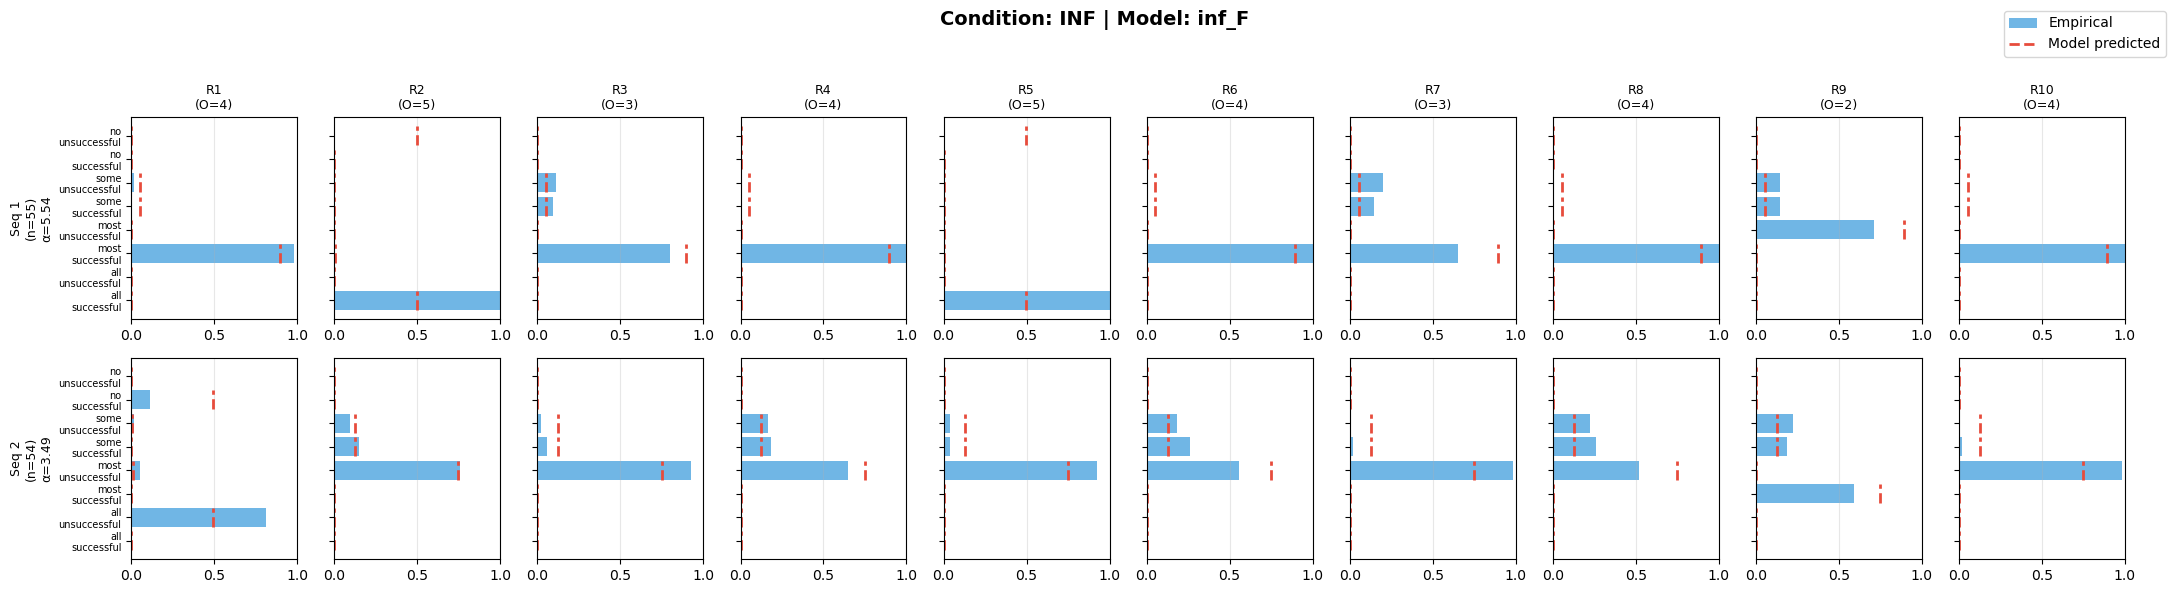


--- PERSP ---
Saved: utterance_dist_persp_persp_F.png


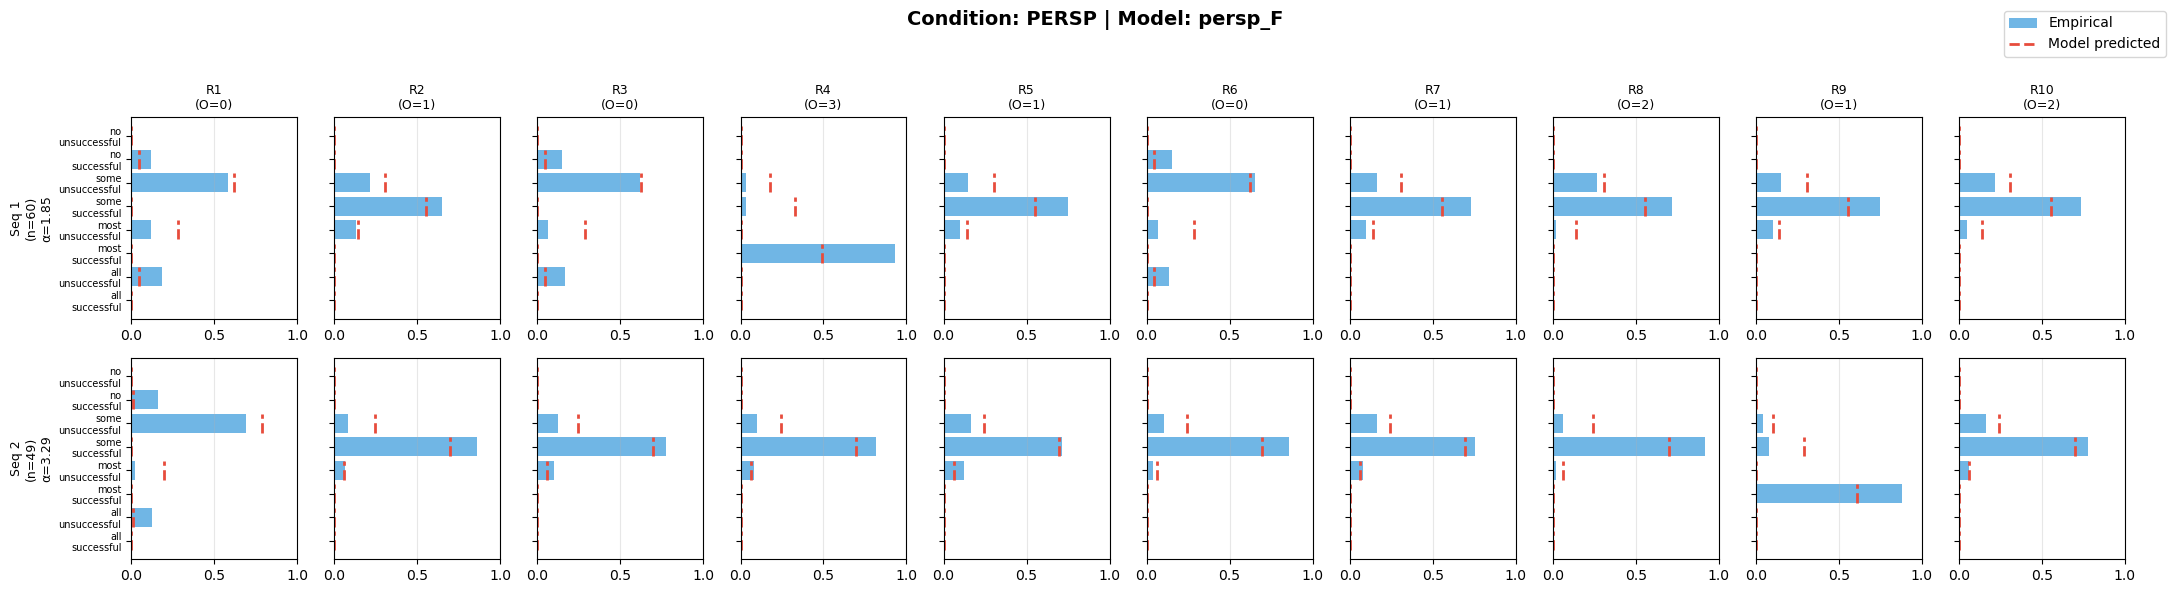


--- PERSM ---
Saved: utterance_dist_persm_persm_F.png


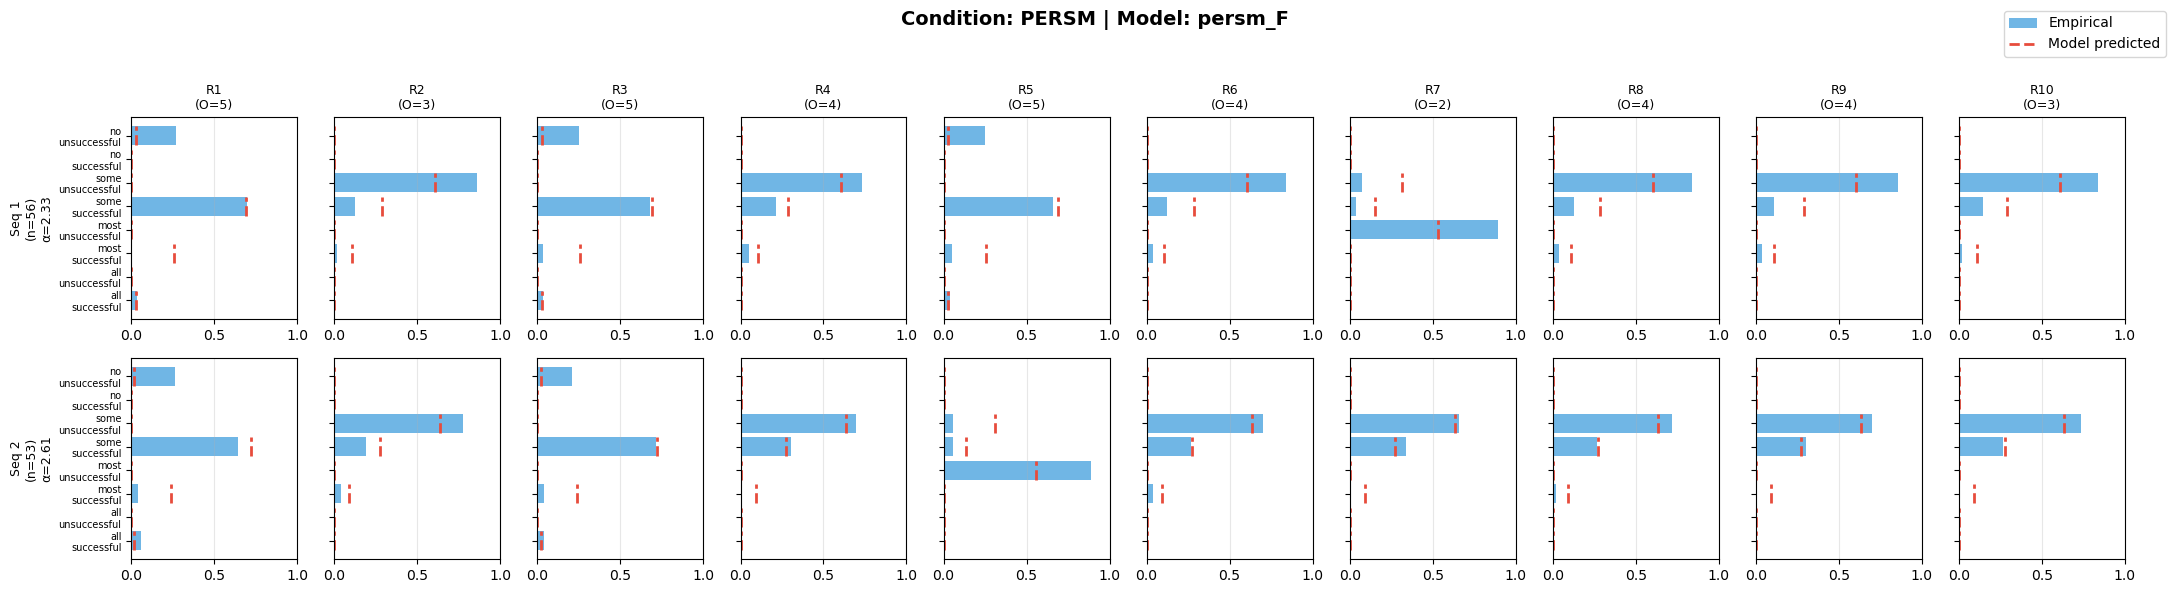

In [24]:
# =============================================================================
# PLOT: EMPIRICAL vs MODEL-PREDICTED UTTERANCE DISTRIBUTIONS
# =============================================================================
#
# For each condition:
#   - Rows: Observation sequences (2 per condition)
#   - Columns: Rounds (1-10)
#   - Each subplot: 
#       - Bars: Empirical proportion of each utterance
#       - Dashed lines: Model-predicted probability
#
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import Counter

def get_model_predictions(
    world: World,
    obs: Tuple[int, ...],
    psi: str,
    update_internal: bool,
    alpha: float,
    speaker: PragmaticSpeaker_obs = None
) -> Dict[str, float]:
    """
    Get model-predicted probabilities for each utterance given an observation.
    
    If speaker is provided (for dynamic models), use it directly.
    Otherwise create a new speaker.
    """
    if speaker is None:
        speaker = PragmaticSpeaker_obs(
            world=world,
            omega="strat",
            psi=psi,
            update_internal=update_internal,
            alpha=alpha,
            beta=0.0,
            initial_beliefs_theta=None
        )
    
    obs_key = tuple(obs) if not isinstance(obs, tuple) else obs
    
    # Get log probabilities and convert to probabilities
    log_probs = speaker.utterance_log_prob_obs[obs_key]
    probs = np.exp(log_probs)
    
    return dict(zip(log_probs.index, probs))


def compute_empirical_distribution(
    participants: List[Dict[str, Any]],
    round_idx: int,
    all_utterances: List[str]
) -> Dict[str, float]:
    """
    Compute empirical proportion of each utterance at a given round.
    """
    utterances_at_round = [p['utt_seq'][round_idx] for p in participants]
    counts = Counter(utterances_at_round)
    total = len(utterances_at_round)
    
    return {utt: counts.get(utt, 0) / total for utt in all_utterances}


def plot_condition_comparison(
    df: pd.DataFrame,
    condition: str,
    model_name: str,
    psi: str,
    update_internal: bool,
    df_obs_seq_fit: pd.DataFrame,
    figsize: Tuple[int, int] = (20, 8),
    save_path: str = None
):
    """
    Plot empirical vs model-predicted distributions for one condition.
    
    Parameters
    ----------
    df : pd.DataFrame
        Raw participant data
    condition : str
        Condition name ('inf', 'persp', 'persm')
    model_name : str
        Model name for display (e.g., 'inf_F')
    psi : str
        Speaker psi parameter ('inf', 'pers+', 'pers-')
    update_internal : bool
        Whether speaker updates internal beliefs
    df_obs_seq_fit : pd.DataFrame
        Observation sequence level fitting results
    """
    
    world = create_world(n=N_EXPERIMENTS, m=M_PATIENTS)
    groups = group_participants_by_obs_sequence(df, condition)
    
    # Get all utterances in consistent order
    ref_speaker = PragmaticSpeaker_obs(
        world=world, omega="strat", psi=psi,
        update_internal=False, alpha=1.0, beta=0.0,
        initial_beliefs_theta=None
    )
    all_utterances = list(ref_speaker.utility.index)
    n_utterances = len(all_utterances)
    
    # Sort groups by size (to match seq_1, seq_2 ordering)
    sorted_groups = sorted(groups.items(), key=lambda x: -len(x[1]))
    n_sequences = len(sorted_groups)
    n_rounds = 10
    
    # Create figure
    fig, axes = plt.subplots(n_sequences, n_rounds, figsize=figsize)
    if n_sequences == 1:
        axes = axes.reshape(1, -1)
    
    # Color scheme
    bar_color = '#3498db'
    line_color = '#e74c3c'
    
    # Shorter utterance labels for display
    utt_labels = [u.replace(',', '\n') for u in all_utterances]
    
    for seq_idx, (obs_key, participants) in enumerate(sorted_groups):
        seq_label = f"seq_{seq_idx + 1}"
        
        # Get fitted alpha for this sequence
        fit_row = df_obs_seq_fit[
            (df_obs_seq_fit['condition'] == condition) & 
            (df_obs_seq_fit['obs_sequence'] == seq_label) &
            (df_obs_seq_fit['model'] == model_name)
        ]
        
        if len(fit_row) > 0:
            fitted_alpha = fit_row['optimal_alpha'].values[0]
            if fitted_alpha == 'determ':
                fitted_alpha = 100.0  # Use high alpha for deterministic
        else:
            fitted_alpha = 1.0  # Default
        
        # Create speaker for this sequence (for dynamic models, need to track state)
        if update_internal:
            # For dynamic models, create fresh speaker for each sequence
            speaker = PragmaticSpeaker_obs(
                world=world, omega="strat", psi=psi,
                update_internal=True, alpha=fitted_alpha, beta=0.0,
                initial_beliefs_theta=None
            )
        else:
            # For static models, create once
            speaker = PragmaticSpeaker_obs(
                world=world, omega="strat", psi=psi,
                update_internal=False, alpha=fitted_alpha, beta=0.0,
                initial_beliefs_theta=None
            )
        
        # Get the observation sequence
        sample_obs_seq = participants[0]['obs_seq']
        
        for round_idx in range(n_rounds):
            ax = axes[seq_idx, round_idx]
            
            # Get observation for this round
            obs = sample_obs_seq[round_idx]
            obs_key_tuple = tuple(obs) if not isinstance(obs, tuple) else obs
            
            # Compute empirical distribution
            empirical = compute_empirical_distribution(participants, round_idx, all_utterances)
            empirical_props = [empirical[u] for u in all_utterances]
            
            # Get model predictions
            log_probs = speaker.utterance_log_prob_obs[obs_key_tuple]
            model_probs = np.exp(log_probs.values)
            
            # Plot bars (empirical)
            y_pos = np.arange(n_utterances)
            ax.barh(y_pos, empirical_props, color=bar_color, alpha=0.7, label='Empirical')
            
            # Plot dashed lines (model)
            for i, prob in enumerate(model_probs):
                ax.plot([prob, prob], [i - 0.4, i + 0.4], 
                       color=line_color, linestyle='--', linewidth=2)
            
            # Formatting
            ax.set_xlim(0, 1)
            ax.set_yticks(y_pos)
            
            if round_idx == 0:
                ax.set_yticklabels(utt_labels, fontsize=7)
                ax.set_ylabel(f'Seq {seq_idx + 1}\n(n={len(participants)})', fontsize=10)
            else:
                ax.set_yticklabels([])
            
            if seq_idx == 0:
                # Get num_effective for this observation
                num_eff = sum(i * obs[i] for i in range(len(obs)))
                ax.set_title(f'R{round_idx + 1}\n(O={num_eff})', fontsize=9)
            
            if seq_idx == n_sequences - 1:
                ax.set_xlabel('Prop.', fontsize=8)
            
            # Update speaker for dynamic models
            if update_internal and round_idx < n_rounds - 1:
                # Get most common utterance at this round for belief update
                # (or we could use a representative utterance)
                # For simplicity, update with the first participant's utterance
                utt = participants[0]['utt_seq'][round_idx]
                speaker.literal_listener.listen_and_update(utt)
                speaker.utterance_log_prob_obs = speaker._compute_utterance_log_prob_obs(speaker.alpha)
    
    # Add legend
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    legend_elements = [
        Patch(facecolor=bar_color, alpha=0.7, label='Empirical'),
        Line2D([0], [0], color=line_color, linestyle='--', linewidth=2, label='Model')
    ]
    fig.legend(handles=legend_elements, loc='upper right', fontsize=10)
    
    # Title
    alpha_str = f"{fitted_alpha:.2f}" if isinstance(fitted_alpha, float) else fitted_alpha
    fig.suptitle(f'Condition: {condition.upper()} | Model: {model_name} | Fitted α by sequence', 
                 fontsize=14, fontweight='bold')
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    
    plt.show()


def plot_all_conditions(
    df: pd.DataFrame,
    df_obs_seq_fit: pd.DataFrame,
    model_config: Dict[str, Tuple[str, str, bool]] = None
):
    """
    Plot comparisons for all conditions.
    
    Parameters
    ----------
    model_config : Dict mapping condition -> (model_name, psi, update_internal)
        If None, uses the best-fitting model for each condition based on df_obs_seq_fit
    """
    
    if model_config is None:
        # Default: use matched model for each condition
        model_config = {
            'inf': ('inf_F', 'inf', False),
            'persp': ('persp_F', 'pers+', False),
            'persm': ('persm_F', 'pers-', False)
        }
    
    for condition in GOAL_CONDITIONS:
        model_name, psi, update_internal = model_config[condition]
        
        print(f"\n{'='*70}")
        print(f"Plotting: {condition.upper()} with model {model_name}")
        print(f"{'='*70}")
        
        plot_condition_comparison(
            df=df,
            condition=condition,
            model_name=model_name,
            psi=psi,
            update_internal=update_internal,
            df_obs_seq_fit=df_obs_seq_fit,
            figsize=(22, 6),
            save_path=f'utterance_dist_{condition}_{model_name}.png'
        )


# =============================================================================
# ALTERNATIVE: Static model version (simpler, no belief update tracking)
# =============================================================================

def plot_condition_comparison_static(
    df: pd.DataFrame,
    condition: str,
    model_name: str,
    psi: str,
    df_obs_seq_fit: pd.DataFrame,
    figsize: Tuple[int, int] = (22, 6),
    save_path: str = None
):
    """
    Plot empirical vs model-predicted distributions for static models only.
    (Simpler version that doesn't need to track belief updates)
    """
    
    world = create_world(n=N_EXPERIMENTS, m=M_PATIENTS)
    groups = group_participants_by_obs_sequence(df, condition)
    
    # Sort groups by size
    sorted_groups = sorted(groups.items(), key=lambda x: -len(x[1]))
    n_sequences = len(sorted_groups)
    n_rounds = 10
    
    # Create figure
    fig, axes = plt.subplots(n_sequences, n_rounds, figsize=figsize)
    if n_sequences == 1:
        axes = axes.reshape(1, -1)
    
    # Colors
    bar_color = '#3498db'
    line_color = '#e74c3c'
    
    for seq_idx, (obs_key, participants) in enumerate(sorted_groups):
        seq_label = f"seq_{seq_idx + 1}"
        
        # Get fitted alpha
        fit_row = df_obs_seq_fit[
            (df_obs_seq_fit['condition'] == condition) & 
            (df_obs_seq_fit['obs_sequence'] == seq_label) &
            (df_obs_seq_fit['model'] == model_name)
        ]
        
        if len(fit_row) > 0:
            fitted_alpha = fit_row['optimal_alpha'].values[0]
            if isinstance(fitted_alpha, str) and fitted_alpha == 'determ':
                fitted_alpha = 100.0
        else:
            fitted_alpha = 1.0
        
        # Create speaker with fitted alpha
        speaker = PragmaticSpeaker_obs(
            world=world, omega="strat", psi=psi,
            update_internal=False, alpha=float(fitted_alpha), beta=0.0,
            initial_beliefs_theta=None
        )
        
        all_utterances = list(speaker.utility.index)
        n_utterances = len(all_utterances)
        utt_labels = [u.replace(',', '\n') for u in all_utterances]
        
        # Get observation sequence
        sample_obs_seq = participants[0]['obs_seq']
        
        for round_idx in range(n_rounds):
            ax = axes[seq_idx, round_idx]
            
            # Observation for this round
            obs = sample_obs_seq[round_idx]
            obs_key_tuple = tuple(obs) if not isinstance(obs, tuple) else obs
            
            # Empirical distribution
            utterances_at_round = [p['utt_seq'][round_idx] for p in participants]
            counts = Counter(utterances_at_round)
            total = len(utterances_at_round)
            empirical_props = [counts.get(u, 0) / total for u in all_utterances]
            
            # Model predictions
            log_probs = speaker.utterance_log_prob_obs[obs_key_tuple]
            model_probs = np.exp(log_probs.values)
            
            # Plot
            y_pos = np.arange(n_utterances)
            ax.barh(y_pos, empirical_props, color=bar_color, alpha=0.7)
            
            for i, prob in enumerate(model_probs):
                ax.plot([prob, prob], [i - 0.4, i + 0.4], 
                       color=line_color, linestyle='--', linewidth=2)
            
            # Formatting
            ax.set_xlim(0, 1)
            ax.set_yticks(y_pos)
            
            if round_idx == 0:
                ax.set_yticklabels(utt_labels, fontsize=7)
                ax.set_ylabel(f'Seq {seq_idx + 1}\n(n={len(participants)})\nα={fitted_alpha:.2f}', 
                             fontsize=9)
            else:
                ax.set_yticklabels([])
            
            if seq_idx == 0:
                num_eff = sum(i * obs[i] for i in range(len(obs)))
                ax.set_title(f'R{round_idx + 1}\n(O={num_eff})', fontsize=9)
            
            # Grid
            ax.set_xticks([0, 0.5, 1.0])
            ax.grid(axis='x', alpha=0.3)
    
    # Legend
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    legend_elements = [
        Patch(facecolor=bar_color, alpha=0.7, label='Empirical'),
        Line2D([0], [0], color=line_color, linestyle='--', linewidth=2, label='Model predicted')
    ]
    fig.legend(handles=legend_elements, loc='upper right', fontsize=10, 
               bbox_to_anchor=(0.99, 0.99))
    
    fig.suptitle(f'Condition: {condition.upper()} | Model: {model_name}', 
                 fontsize=14, fontweight='bold')
    
    plt.tight_layout(rect=[0, 0, 0.98, 0.94])
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    
    plt.show()


# =============================================================================
# RUN PLOTS
# =============================================================================

print("="*70)
print("PLOTTING EMPIRICAL vs MODEL PREDICTED UTTERANCE DISTRIBUTIONS")
print("="*70)

# Plot each condition with its matched model
for condition, (model_name, psi) in [
    ('inf', ('inf_F', 'inf')),
    ('persp', ('persp_F', 'pers+')),
    ('persm', ('persm_F', 'pers-'))
]:
    print(f"\n--- {condition.upper()} ---")
    plot_condition_comparison_static(
        df=df,
        condition=condition,
        model_name=model_name,
        psi=psi,
        df_obs_seq_fit=df_obs_seq_fit,
        figsize=(22, 6),
        save_path=f'utterance_dist_{condition}_{model_name}.png'
    )